In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
import zipfile

zip_file = "archive.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("data")

In [4]:
import os

os.listdir("data")

['securities.csv',
 'fundamentals.csv',
 'prices-split-adjusted.csv',
 'prices.csv']

In [6]:
import pandas as pd

fundamentals = pd.read_csv("data/fundamentals.csv")
prices = pd.read_csv("data/prices-split-adjusted.csv")
securities = pd.read_csv("data/securities.csv")

fundamentals.head()

,Unnamed: 0,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,...,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
0,0,AAL,2012-12-31,3.068000e+09,-222000000.0,-1.961000e+09,23.0,-1.888000e+09,4.695000e+09,53.0,...,7.072000e+09,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.60,3.350000e+08
1,1,AAL,2013-12-31,4.975000e+09,-93000000.0,-2.723000e+09,67.0,-3.114000e+09,1.059200e+10,75.0,...,1.432300e+10,1.380600e+10,-2.731000e+09,4.500900e+10,4.227800e+10,2.674300e+10,0.0,2013.0,-11.25,1.630222e+08
2,2,AAL,2014-12-31,4.668000e+09,-160000000.0,-1.500000e+08,143.0,-5.311000e+09,1.513500e+10,60.0,...,1.175000e+10,1.340400e+10,2.021000e+09,4.120400e+10,4.322500e+10,4.265000e+10,0.0,2014.0,4.02,7.169154e+08
3,3,AAL,2015-12-31,5.102000e+09,352000000.0,-7.080000e+08,135.0,-6.151000e+09,1.159100e+10,51.0,...,9.985000e+09,1.360500e+10,5.635000e+09,4.278000e+10,4.841500e+10,4.099000e+10,0.0,2015.0,11.39,6.681299e+08
4,4,AAP,2012-12-29,2.409453e+09,-89482000.0,6.000000e+05,32.0,-2.711820e+08,5.202150e+08,23.0,...,3.184200e+09,2.559638e+09,1.210694e+09,3.403120e+09,4.613814e+09,6.205003e+09,-27095000.0,2012.0,5.29,7.328355e+07


In [7]:
fundamentals.info()

prices.info()

securities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 79 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Unnamed: 0                                           1781 non-null   int64  
 1   Ticker Symbol                                        1781 non-null   object 
 2   Period Ending                                        1781 non-null   object 
 3   Accounts Payable                                     1781 non-null   float64
 4   Accounts Receivable                                  1781 non-null   float64
 5   Add'l income/expense items                           1781 non-null   float64
 6   After Tax ROE                                        1781 non-null   float64
 7   Capital Expenditures                                 1781 non-null   float64
 8   Capital Surplus                                      1781 non-null  

In [9]:
fundamentals.columns

Index(['Unnamed: 0', 'Ticker Symbol', 'Period Ending', 'Accounts Payable',
       'Accounts Receivable', 'Add'l income/expense items', 'After Tax ROE',
       'Capital Expenditures', 'Capital Surplus', 'Cash Ratio',
       'Cash and Cash Equivalents', 'Changes in Inventories', 'Common Stocks',
       'Cost of Revenue', 'Current Ratio', 'Deferred Asset Charges',
       'Deferred Liability Charges', 'Depreciation',
       'Earnings Before Interest and Tax', 'Earnings Before Tax',
       'Effect of Exchange Rate',
       'Equity Earnings/Loss Unconsolidated Subsidiary', 'Fixed Assets',
       'Goodwill', 'Gross Margin', 'Gross Profit', 'Income Tax',
       'Intangible Assets', 'Interest Expense', 'Inventory', 'Investments',
       'Liabilities', 'Long-Term Debt', 'Long-Term Investments',
       'Minority Interest', 'Misc. Stocks', 'Net Borrowings', 'Net Cash Flow',
       'Net Cash Flow-Operating', 'Net Cash Flows-Financing',
       'Net Cash Flows-Investing', 'Net Income', 'Net Income Ad

In [10]:
fundamentals["ROE"] = fundamentals["Net Income"] / fundamentals["Total Equity"]

fundamentals.head()

,Unnamed: 0,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,...,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding,ROE
0,0,AAL,2012-12-31,3.068000e+09,-222000000.0,-1.961000e+09,23.0,-1.888000e+09,4.695000e+09,53.0,...,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.60,3.350000e+08,0.234882
1,1,AAL,2013-12-31,4.975000e+09,-93000000.0,-2.723000e+09,67.0,-3.114000e+09,1.059200e+10,75.0,...,1.380600e+10,-2.731000e+09,4.500900e+10,4.227800e+10,2.674300e+10,0.0,2013.0,-11.25,1.630222e+08,0.671549
2,2,AAL,2014-12-31,4.668000e+09,-160000000.0,-1.500000e+08,143.0,-5.311000e+09,1.513500e+10,60.0,...,1.340400e+10,2.021000e+09,4.120400e+10,4.322500e+10,4.265000e+10,0.0,2014.0,4.02,7.169154e+08,1.426027
3,3,AAL,2015-12-31,5.102000e+09,352000000.0,-7.080000e+08,135.0,-6.151000e+09,1.159100e+10,51.0,...,1.360500e+10,5.635000e+09,4.278000e+10,4.841500e+10,4.099000e+10,0.0,2015.0,11.39,6.681299e+08,1.350488
4,4,AAP,2012-12-29,2.409453e+09,-89482000.0,6.000000e+05,32.0,-2.711820e+08,5.202150e+08,23.0,...,2.559638e+09,1.210694e+09,3.403120e+09,4.613814e+09,6.205003e+09,-27095000.0,2012.0,5.29,7.328355e+07,0.320205


In [11]:
import numpy as np

fundamentals["ROE"] = fundamentals["ROE"].replace([np.inf, -np.inf], np.nan)

fundamentals = fundamentals.dropna(subset=["ROE"])

In [12]:
fundamentals[["Net Income","Total Equity","ROE"]].head()

,Net Income,Total Equity,ROE
0,-1.876000e+09,-7.987000e+09,0.234882
1,-1.834000e+09,-2.731000e+09,0.671549
2,2.882000e+09,2.021000e+09,1.426027
3,7.610000e+09,5.635000e+09,1.350488
4,3.876700e+08,1.210694e+09,0.320205


In [13]:
prices = pd.read_csv("prices-split-adjusted.csv")

prices.head()

FileNotFoundError: [Errno 2] No such file or directory: 'prices-split-adjusted.csv'

In [14]:
import os
os.listdir()

['.config', 'data', 'archive.zip', 'sample_data']

In [15]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('stock_data')

In [16]:
os.listdir("stock_data")

['securities.csv',
 'fundamentals.csv',
 'prices-split-adjusted.csv',
 'prices.csv']

In [17]:
prices = pd.read_csv("stock_data/prices-split-adjusted.csv")

prices.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


In [18]:
os.listdir()

['.config', 'data', 'archive.zip', 'stock_data', 'sample_data']

In [19]:
import os

os.listdir("/content/stock_data")

['securities.csv',
 'fundamentals.csv',
 'prices-split-adjusted.csv',
 'prices.csv']

In [20]:
prices = pd.read_csv("/content/stock_data/prices-split-adjusted.csv")

prices.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


In [21]:
prices["date"] = pd.to_datetime(prices["date"])

In [22]:
prices["daily_return"] = prices.groupby("symbol")["close"].pct_change()

prices.head()

,date,symbol,open,close,low,high,volume,daily_return
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0,NaN
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0,-0.046567
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0,-0.041924
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0,0.014528
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0,-0.014149


In [23]:
top_returns = prices.groupby("symbol")["daily_return"].mean().sort_values(ascending=False)

top_returns.head(10)

,daily_return
symbol,
EVHC,0.002507
NFLX,0.002228
REGN,0.001929
URI,0.001796
AAL,0.001764
ULTA,0.001761
FB,0.001637
ALK,0.001533
AVGO,0.001520


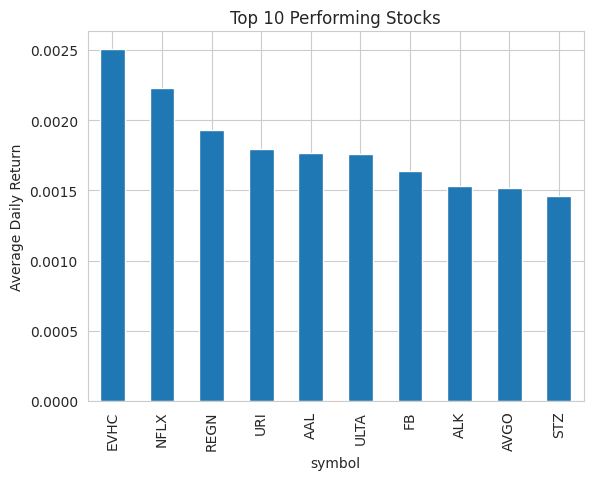

In [24]:
import matplotlib.pyplot as plt

top_returns.head(10).plot(kind="bar")

plt.title("Top 10 Performing Stocks")
plt.ylabel("Average Daily Return")
plt.show()

In [25]:
financial_health = fundamentals.groupby("Ticker Symbol")["ROE"].mean()

financial_health.sort_values(ascending=False).head(10)

,ROE
Ticker Symbol,
LB,12.467160
MJN,8.400161
HRB,4.276762
CLX,3.659564
PBI,2.830633
SPGI,2.505189
BA,1.936305
LMT,1.585512
MO,1.480595


In [26]:
top_returns.head(20).to_csv("top_stock_performance.csv")

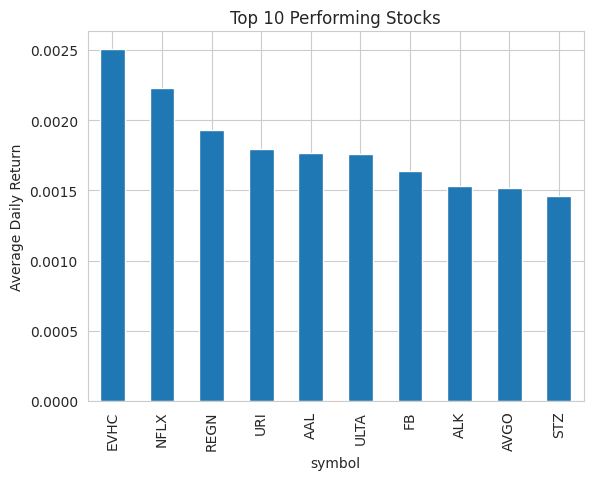

In [27]:
import matplotlib.pyplot as plt

top_returns.head(10).plot(kind="bar")

plt.title("Top 10 Performing Stocks")
plt.ylabel("Average Daily Return")

plt.savefig("stock_performance_chart.png")

plt.show()